# 🗂️ **Skripsi** : ANALISIS SENTIMEN — RANDOM FOREST CLASSIFIER & IndoBERT (Topik: LPDP)

**Author**   : [Nofendra Tahta Dirgantara]

**Pipeline** : Load → Clean → Preprocess → Label → EDA → Model → Tune → Save → Infer


In [ ]:
!pip install sastrawi wordcloud langdetect joblib -q

# IMPORT LIBRARY

In [ ]:
# ── Data Manipulation ────────────────────────────────────────
import re
import os
import json
import warnings
import joblib
import requests
from io import StringIO
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd

# ── Visualisasi ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# ── Deteksi Bahasa ───────────────────────────────────────────
from langdetect import detect, LangDetectException

# ── NLP Indonesia (Sastrawi) ─────────────────────────────────
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ── Machine Learning ─────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Konfigurasi Global ────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Warna konsisten untuk 3 kelas sentimen
SENTIMENT_COLORS = {
    "Positif": "#2ecc71",
    "Netral":  "#3498db",
    "Negatif": "#e74c3c",
}

print("✅ Semua library berhasil diimport.")

✅ Semua library berhasil diimport.


# LOAD DATASET

In [ ]:
DATASET_URL = (
    "https://raw.githubusercontent.com/go0se05/Analysis-Sentiment_LPDP"
    "/refs/heads/main/master_data_lpdp.csv"
)
COLS_TO_USE = ["id_str", "created_at", "full_text", "lang"]

print("📥 Memuat dataset dari GitHub ...")
df = pd.read_csv(DATASET_URL, low_memory=False)

# Pastikan kolom yang dibutuhkan tersedia
missing_cols = [c for c in COLS_TO_USE if c not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut tidak ada di dataset: {missing_cols}")

# Ambil hanya kolom yang relevan
df = df[COLS_TO_USE].copy()

print(f"\n📊 Informasi Dataset Awal:")
print(f"  Jumlah baris   : {df.shape[0]:,}")
print(f"  Jumlah kolom   : {df.shape[1]}")
print(f"  Kolom          : {list(df.columns)}")
print(f"\n🔍 5 Data Pertama (transpos agar full_text terbaca):")

df.head(5)

📥 Memuat dataset dari GitHub ...

📊 Informasi Dataset Awal:
  Jumlah baris   : 2,354
  Jumlah kolom   : 4
  Kolom          : ['id_str', 'created_at', 'full_text', 'lang']

🔍 5 Data Pertama (transpos agar full_text terbaca):


,id_str,created_at,full_text,lang
0,2043718234973860099,Mon Apr 13 15:49:32 +0000 2026,@dearkangbra gak memegang prinsip cukup aku aj...,in
1,2043291003906654504,Sun Apr 12 11:31:52 +0000 2026,@Soyasoy18190804 @GunakanOtakKau @MeeRebus11 I...,in
2,2043259169130881509,Sun Apr 12 09:25:22 +0000 2026,@Gooren26 @GunakanOtakKau @MeeRebus11 Anti Mal...,in
3,2042531874871075166,Fri Apr 10 09:15:22 +0000 2026,@semesta_han @Kimmywithyou Sabar cukup aku aja...,in
4,2040226887407136770,Sat Apr 04 00:36:10 +0000 2026,@WatchmenID Cukup aku aja yang WNI anakku jangan,in


# DATA CLEANING

### Cek Missing Values & Duplikat

In [ ]:
print("=" * 55)
print("📋 STATUS AWAL DATA")
print("=" * 55)
print(f"  Total baris            : {len(df):,}")
print(f"  Duplikat (full_text)   : {df.duplicated(subset='full_text').sum():,}")
print(f"\n  Missing values per kolom:")
print(df.isnull().sum().to_string())

📋 STATUS AWAL DATA
  Total baris            : 2,354
  Duplikat (full_text)   : 222

  Missing values per kolom:
id_str        0
created_at    0
full_text     0
lang          0


### Hapus NA & Duplikat

In [ ]:
before = len(df)

# Langkah 1 — Hapus baris dengan missing value di kolom full_text
df = df.dropna(subset=["full_text"]).copy()
after_na = len(df)

# Langkah 2 — Hapus duplikat berdasarkan teks
df = df.drop_duplicates(subset="full_text", keep="first").reset_index(drop=True)
after_dup = len(df)

print("=" * 55)
print("✅ STATUS SETELAH CLEANING")
print("=" * 55)
print(f"  Baris awal             : {before:,}")
print(f"  Setelah hapus NA       : {after_na:,}  (dihapus: {before - after_na:,})")
print(f"  Setelah hapus duplikat : {after_dup:,}  (dihapus: {after_na - after_dup:,})")
print(f"  Total baris bersih     : {after_dup:,}")
print(f"\n  Missing values tersisa:")
print(df.isnull().sum().to_string())

print(f"\n📄 Contoh data bersih:")

df.head(3)

✅ STATUS SETELAH CLEANING
  Baris awal             : 2,354
  Setelah hapus NA       : 2,354  (dihapus: 0)
  Setelah hapus duplikat : 2,132  (dihapus: 222)
  Total baris bersih     : 2,132

  Missing values tersisa:
id_str        0
created_at    0
full_text     0
lang          0

📄 Contoh data bersih:


,id_str,created_at,full_text,lang
0,2043718234973860099,Mon Apr 13 15:49:32 +0000 2026,@dearkangbra gak memegang prinsip cukup aku aj...,in
1,2043291003906654504,Sun Apr 12 11:31:52 +0000 2026,@Soyasoy18190804 @GunakanOtakKau @MeeRebus11 I...,in
2,2043259169130881509,Sun Apr 12 09:25:22 +0000 2026,@Gooren26 @GunakanOtakKau @MeeRebus11 Anti Mal...,in


# PREPROCESSING

In [ ]:
"""
Menginisialisasi semua komponen NLP Indonesia:
  - Stemmer Sastrawi
  - Stopwords Sastrawi + kustom Twitter Indonesia
  - Kamus normalisasi kata tidak baku da
  ri URL
Diinisialisasi sekali di sini agar efisien (tidak reload berulang).
"""

KAMUS_URL = "https://raw.githubusercontent.com/go0se05/PI/main/kamuskatabaku.csv"

print("🔧 Menginisialisasi komponen NLP ...")

🔧 Menginisialisasi komponen NLP ...


In [ ]:
# ── Stemmer Sastrawi ─────────────────────────────────────────
stemmer = StemmerFactory().create_stemmer()
print("  ✅ Stemmer Sastrawi siap")

# ── Stopwords Sastrawi ────────────────────────────────────────
sw_factory    = StopWordRemoverFactory()
stopwords_set = set(sw_factory.get_stop_words())

# Tambahkan stopword khusus Twitter Indonesia
custom_sw = {
    "yg", "dgn", "nya", "jg", "juga", "ini", "itu", "dan", "atau", "untuk",
    "dengan", "ada", "tidak", "bisa", "aja", "gak", "ga", "gw", "aku",
    "kamu", "saya", "kalian", "kita", "mereka", "dia", "udah", "sudah",
    "jadi", "ya", "sih", "deh", "nih", "lah", "dong", "banget", "bgt",
    "wkwk", "haha", "lol", "wah", "oh", "ah", "eh", "hm",
    "rt", "amp", "via", "cc", "https", "http", "co", "www",
}
stopwords_set.update(custom_sw)
print(f"  ✅ Stopwords siap ({len(stopwords_set):,} kata)")

# ── Kamus Kata Tidak Baku → Baku ─────────────────────────────
try:
    kamus_df  = pd.read_csv(KAMUS_URL)
    # Deteksi nama kolom secara fleksibel
    cols = kamus_df.columns.str.lower().tolist()
    if "tidak_baku" in cols and "kata_baku" in cols:
        kamus_baku = dict(zip(kamus_df["tidak_baku"], kamus_df["kata_baku"]))
    else:
        kamus_baku = dict(zip(kamus_df.iloc[:, 0], kamus_df.iloc[:, 1]))
    print(f"  ✅ Kamus kata baku dimuat ({len(kamus_baku):,} entri dari URL)")

except Exception as e:
    print(f"  ⚠️  Gagal memuat kamus dari URL: {e}")
    print("  📌 Menggunakan placeholder kamus — silakan lengkapi sesuai kebutuhan")
    # ── PLACEHOLDER KAMUS — Isi/tambah entri sesuai data Anda ──────────────
    kamus_baku = {
        "gak": "tidak",   "ga": "tidak",    "udah": "sudah",
        "gimana": "bagaimana", "kalo": "kalau", "aja": "saja",
        "bgt": "banget",  "yg": "yang",      "dgn": "dengan",
        "tdk": "tidak",   "blm": "belum",    "sdh": "sudah",
        "krn": "karena",  "utk": "untuk",    "lg": "lagi",
        "emg": "memang",  "ttp": "tetap",    "hrs": "harus",
        "pake": "pakai",  "pengen": "ingin", "kmrn": "kemarin",
        "abis": "habis",  "bikin": "membuat","nggak": "tidak",
    }
    # ── AKHIR PLACEHOLDER ────────────────────────────────────────────────────
    print(f"  ✅ Placeholder kamus siap ({len(kamus_baku)} entri)")

print("\n🎯 Semua komponen NLP berhasil diinisialisasi.")

  ✅ Stemmer Sastrawi siap
  ✅ Stopwords siap (158 kata)
  ✅ Kamus kata baku dimuat (9,712 entri dari URL)

🎯 Semua komponen NLP berhasil diinisialisasi.


In [ ]:
# ── Fungsi 1: Filtering ──────────────────────────────────────
def filter_teks(text: str) -> str:
    """
    Membersihkan teks dari elemen Twitter yang tidak relevan:
      - URL (http/https)
      - Mention (@username)
      - Hashtag (simbol # dihapus, kata tetap)
      - Emoji unicode
      - Angka
      - Tanda baca dan karakter non-alfabet
      - Spasi berlebih
    """
    if not isinstance(text, str):
        return ""
    # Hapus URL
    text = re.sub(r"http\S+|www\S+", " ", text)
    # Hapus mention
    text = re.sub(r"@\w+", " ", text)
    # Hapus simbol # tapi pertahankan kata
    text = re.sub(r"#(\w+)", r"\1", text)
    # Hapus emoji unicode
    emoji_pat = re.compile(
        "[" "\U0001F600-\U0001F64F" "\U0001F300-\U0001F5FF"
            "\U0001F680-\U0001F6FF" "\U0001F700-\U0001F77F"
            "\U0001F780-\U0001F7FF" "\U0001F800-\U0001F8FF"
            "\U0001F900-\U0001F9FF" "\U0001FA00-\U0001FA6F"
            "\U0001FA70-\U0001FAFF" "\U00002702-\U000027B0" "]+",
        flags=re.UNICODE,
    )
    text = emoji_pat.sub(" ", text)
    # Hapus angka
    text = re.sub(r"\d+", " ", text)
    # Hapus tanda baca & karakter non-alfabet
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"_+", " ", text)
    # Normalisasi spasi
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ── Fungsi 2: Case Folding ───────────────────────────────────
def case_folding(text: str) -> str:
    """Mengubah seluruh teks menjadi huruf kecil (lowercase)."""
    return text.lower()


# ── Fungsi 3: Deteksi Bahasa ─────────────────────────────────
def is_indonesian(text: str) -> bool:
    """
    Mendeteksi apakah teks berbahasa Indonesia menggunakan langdetect.
    Teks < 3 kata diasumsikan Indonesia (terlalu pendek untuk dideteksi).
    Mengembalikan True  → bahasa Indonesia, pertahankan.
    Mengembalikan False → bahasa asing, buang.
    """
    if len(text.split()) < 3:
        return True
    try:
        return detect(text) == "id"
    except LangDetectException:
        return True


# ── Fungsi 4: Normalisasi Kata Tidak Baku ────────────────────
def normalisasi_kata(text: str, kamus: dict) -> str:
    """
    Mengganti kata slang/alay/tidak baku dengan padanan bakunya
    berdasarkan kamus yang telah dimuat dari URL.
    Contoh: 'gak' → 'tidak', 'udah' → 'sudah'
    """
    words     = text.split()
    normalized = [kamus.get(w, w) for w in words]
    return " ".join(normalized)


# ── Fungsi 5: Hapus Stopwords ────────────────────────────────
def hapus_stopwords(text: str, sw_set: set) -> str:
    """
    Menghapus kata-kata yang tidak membawa makna sentimen
    (kata hubung, kata ganti, dsb.) dari teks.
    Kata dengan panjang ≤ 1 karakter juga dihapus.
    """
    words    = text.split()
    filtered = [w for w in words if w not in sw_set and len(w) > 1]
    return " ".join(filtered)


# ── Fungsi 6: Stemming (Sastrawi) ────────────────────────────
def lakukan_stemming(text: str, stmr) -> str:
    """
    Memotong kata ke bentuk dasarnya menggunakan Sastrawi.
    Dirancang khusus untuk Bahasa Indonesia.
    Contoh: 'pembelajaran' → 'ajar', 'beasiswa' → 'siswa'
    """
    if not text.strip():
        return ""
    return stmr.stem(text)


print("✅ Semua fungsi preprocessing berhasil didefinisikan:")
print("   1. filter_teks()       — Hapus URL, mention, hashtag, emoji, angka")
print("   2. case_folding()      — Lowercase")
print("   3. is_indonesian()     — Deteksi bahasa")
print("   4. normalisasi_kata()  — Ganti kata tidak baku")
print("   5. hapus_stopwords()   — Hapus stopwords")
print("   6. lakukan_stemming()  — Stemming Sastrawi")

✅ Semua fungsi preprocessing berhasil didefinisikan:
   1. filter_teks()       — Hapus URL, mention, hashtag, emoji, angka
   2. case_folding()      — Lowercase
   3. is_indonesian()     — Deteksi bahasa
   4. normalisasi_kata()  — Ganti kata tidak baku
   5. hapus_stopwords()   — Hapus stopwords
   6. lakukan_stemming()  — Stemming Sastrawi


In [ ]:
contoh = "Alhamdulillah akhirnya lolos LPDP! 🎉 Bgt seneng banget, " \
         "udah nunggu lama bgt @LPDP_RI #beasiswa https://lpdp.go.id 2024"

print("=" * 60)
print("🔬 CONTOH TAHAP-PER-TAHAP PREPROCESSING")
print("=" * 60)
print(f"\n  [0] Teks asli       : {contoh}")

tahap1 = filter_teks(contoh)
print(f"\n  [1] Filter          : {tahap1}")

tahap2 = case_folding(tahap1)
print(f"\n  [2] Case folding    : {tahap2}")

cek_lang = is_indonesian(tahap2)
print(f"\n  [3] Bahasa Indo?    : {'Ya ✅' if cek_lang else 'Bukan (akan dibuang) ❌'}")

tahap4 = normalisasi_kata(tahap2, kamus_baku)
print(f"\n  [4] Normalisasi     : {tahap4}")

tahap5 = hapus_stopwords(tahap4, stopwords_set)
print(f"\n  [5] Stopwords hapus : {tahap5}")

tahap6 = lakukan_stemming(tahap5, stemmer)
print(f"\n  [6] Stemming        : {tahap6}")
print("\n" + "=" * 60)

🔬 CONTOH TAHAP-PER-TAHAP PREPROCESSING

  [0] Teks asli       : Alhamdulillah akhirnya lolos LPDP! 🎉 Bgt seneng banget, udah nunggu lama bgt @LPDP_RI #beasiswa https://lpdp.go.id 2024

  [1] Filter          : Alhamdulillah akhirnya lolos LPDP Bgt seneng banget udah nunggu lama bgt beasiswa

  [2] Case folding    : alhamdulillah akhirnya lolos lpdp bgt seneng banget udah nunggu lama bgt beasiswa

  [3] Bahasa Indo?    : Ya ✅

  [4] Normalisasi     : alhamdulillah akhirnya lolos lpdp banget senang banget sudah menunggu lama banget beasiswa

  [5] Stopwords hapus : alhamdulillah akhirnya lolos lpdp senang menunggu lama beasiswa

  [6] Stemming        : alhamdulillah akhir lolos lpdp senang tunggu lama beasiswa



In [ ]:
"""
Menjalankan pipeline preprocessing lengkap ke seluruh kolom full_text.
Teks yang kosong setelah preprocessing akan dihapus dari dataset.
"""

def preprocess_pipeline(text: str) -> str:
    """
    Satu fungsi pipeline yang merangkai ke-6 tahap preprocessing secara berurutan:
      filter → lowercase → cek bahasa → normalisasi → stopwords → stemming
    Mengembalikan string kosong jika teks bukan bahasa Indonesia atau terlalu pendek.
    """
    text = filter_teks(text)
    if not text:
        return ""
    text = case_folding(text)
    if not is_indonesian(text):
        return ""   # Buang teks non-Indonesia
    text = normalisasi_kata(text, kamus_baku)
    text = hapus_stopwords(text, stopwords_set)
    text = lakukan_stemming(text, stemmer)
    return text

print(f"⚙️  Memproses {len(df):,} tweet ... (proses ini membutuhkan beberapa menit)")

df["processed_text"] = df["full_text"].apply(preprocess_pipeline)

# Hapus baris yang hasil preprocessingnya kosong
before_prep = len(df)
df = df[df["processed_text"].str.strip().str.len() > 0].reset_index(drop=True)
after_prep  = len(df)

print(f"\n✅ Preprocessing selesai!")
print(f"  Baris sebelum : {before_prep:,}")
print(f"  Baris sesudah : {after_prep:,}  (dibuang: {before_prep - after_prep:,} teks kosong/asing)")

print(f"\n📄 Hasil preprocessing (5 baris pertama):")
df[["full_text", "processed_text"]].head()

⚙️  Memproses 2,132 tweet ... (proses ini membutuhkan beberapa menit)

✅ Preprocessing selesai!
  Baris sebelum : 2,132
  Baris sesudah : 1,902  (dibuang: 230 teks kosong/asing)

📄 Hasil preprocessing (5 baris pertama):


,full_text,processed_text
0,@dearkangbra gak memegang prinsip cukup aku aj...,pegang prinsip cukup warga negara indonesia an...
1,@Soyasoy18190804 @GunakanOtakKau @MeeRebus11 I...,indonesia butuh manusia biar warga negara indo...
2,@Gooren26 @GunakanOtakKau @MeeRebus11 Anti Mal...,anti malaysia wujud istilah jasad indonesia pe...
3,@semesta_han @Kimmywithyou Sabar cukup aku aja...,sabar cukup warga negara indonesia anak jangan
4,@WatchmenID Cukup aku aja yang WNI anakku jangan,cukup warga negara indonesia anak jangan


# PELABELAN

### Load Leksikon InSet Fajri

In [ ]:
"""
Memuat leksikon sentimen InSet (Fajri et al.) dari GitHub:
  - positive.tsv : kata → bobot positif
  - negative.tsv : kata → bobot negatif
Leksikon ini dirancang khusus untuk Bahasa Indonesia.
"""

LEXICON_POS_URL = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
LEXICON_NEG_URL = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

def _load_tsv_lexicon(url: str) -> dict:
    """
    Memuat file TSV leksikon dan mengembalikan
    dictionary {kata: bobot_integer}
    """

    r = requests.get(url, timeout=30)
    r.raise_for_status()

    df_lex = pd.read_csv(
        StringIO(r.text),
        sep="\t",
        header=None,
        names=["word", "weight"]
    )

    df_lex["word"] = (
        df_lex["word"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    # PENTING
    df_lex["weight"] = pd.to_numeric(
        df_lex["weight"],
        errors="coerce"
    )

    df_lex = df_lex.dropna(subset=["weight"])

    df_lex["weight"] = df_lex["weight"].astype(int)

    return dict(
        zip(
            df_lex["word"],
            df_lex["weight"]
        )
    )

print("📥 Memuat leksikon InSet Fajri ...")
lexicon_pos = _load_tsv_lexicon(LEXICON_POS_URL)
lexicon_neg = _load_tsv_lexicon(LEXICON_NEG_URL)

# Hapus kata yang muncul di keduanya (konflik)
konflik = set(lexicon_pos.keys()) & set(lexicon_neg.keys())
for k in konflik:
    del lexicon_pos[k]
    del lexicon_neg[k]

print(f"\n📊 Statistik Leksikon:")
print(f"  Kata positif : {len(lexicon_pos):,}")
print(f"  Kata negatif : {len(lexicon_neg):,}")
print(f"  Konflik dihapus : {len(konflik):,} kata")
print(f"\n  Contoh kata positif : {list(lexicon_pos.keys())[:8]}")
print(f"  Contoh kata negatif : {list(lexicon_neg.keys())[:8]}")

📥 Memuat leksikon InSet Fajri ...

📊 Statistik Leksikon:
  Kata positif : 2,465
  Kata negatif : 5,464
  Konflik dihapus : 1,142 kata

  Contoh kata positif : ['hai', 'merekam', 'ekstensif', 'paripurna', 'detail', 'pernik', 'hello', 'promo']
  Contoh kata negatif : ['putus tali gantung', 'gobar hati', 'tersentuh (perasaan)', 'isak', 'larat hati', 'nelangsa', 'remuk redam', 'salah benang']


In [ ]:
"""
Melabeli setiap tweet dengan pendekatan Lexicon-Based:
  skor = Σ bobot_positif - Σ |bobot_negatif|  untuk setiap token
  skor > 0  → Positif
  skor < 0  → Negatif
  skor == 0 → Netral
"""

def label_sentimen(text: str) -> tuple:
    """
    Menghitung skor sentimen dan menentukan kelas.
    Mengembalikan (skor, label_string).
    """
    if not isinstance(text, str) or not text.strip():
        return 0, "Netral"
    skor = 0
    for token in text.split():
        skor += lexicon_pos.get(token, 0)
        skor -= abs(lexicon_neg.get(token, 0))
    if skor > 0:
        return skor, "Positif"
    elif skor < 0:
        return skor, "Negatif"
    else:
        return 0, "Netral"

# Terapkan ke DataFrame
df[["Score", "label"]] = df["processed_text"].apply(
    lambda t: pd.Series(label_sentimen(t))
)

# Tampilkan distribusi
dist = df["label"].value_counts()
print("✅ Pelabelan selesai!\n")
print("📊 Distribusi Kelas Sentimen:")
for kls, jml in dist.items():
    pct = jml / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {kls:<10} : {jml:>6,} ({pct:>5.1f}%)  {bar}")

print(f"\n📄 Contoh hasil pelabelan (10 baris):")
df[["full_text", "processed_text", "Score", "label"]].head(10)

✅ Pelabelan selesai!

📊 Distribusi Kelas Sentimen:
  Negatif    :  1,187 ( 62.4%)  ███████████████████████████████
  Positif    :    597 ( 31.4%)  ███████████████
  Netral     :    118 (  6.2%)  ███

📄 Contoh hasil pelabelan (10 baris):


,full_text,processed_text,Score,label
0,@dearkangbra gak memegang prinsip cukup aku aj...,pegang prinsip cukup warga negara indonesia an...,-13,Negatif
1,@Soyasoy18190804 @GunakanOtakKau @MeeRebus11 I...,indonesia butuh manusia biar warga negara indo...,-15,Negatif
2,@Gooren26 @GunakanOtakKau @MeeRebus11 Anti Mal...,anti malaysia wujud istilah jasad indonesia pe...,-11,Negatif
3,@semesta_han @Kimmywithyou Sabar cukup aku aja...,sabar cukup warga negara indonesia anak jangan,-6,Negatif
4,@WatchmenID Cukup aku aja yang WNI anakku jangan,cukup warga negara indonesia anak jangan,-11,Negatif
5,@Urrangawak emang paling bener itu org yg bila...,memang paling benar orang bilang cukup warga n...,-11,Negatif
6,@coffebit cukup aku aja yg wni anakku jangan,cukup warga negara indonesia anak jangan,-11,Negatif
7,@global__south Indonesian diaspora : cukup aku...,indonesia diaspora cukup warga negara indonesi...,-11,Negatif
8,Cukup aku aja yang WNI anakku jangan Mereka na...,cukup warga negara indonesia anak jangan lahir...,-8,Negatif
9,@nico_inoo @insidefolkative Karena pernyataann...,nyata viral tunjuk paspor inggris anak bilang ...,-13,Negatif


# EDA

### Distribusi Sentimen (Bar + Pie Chart)

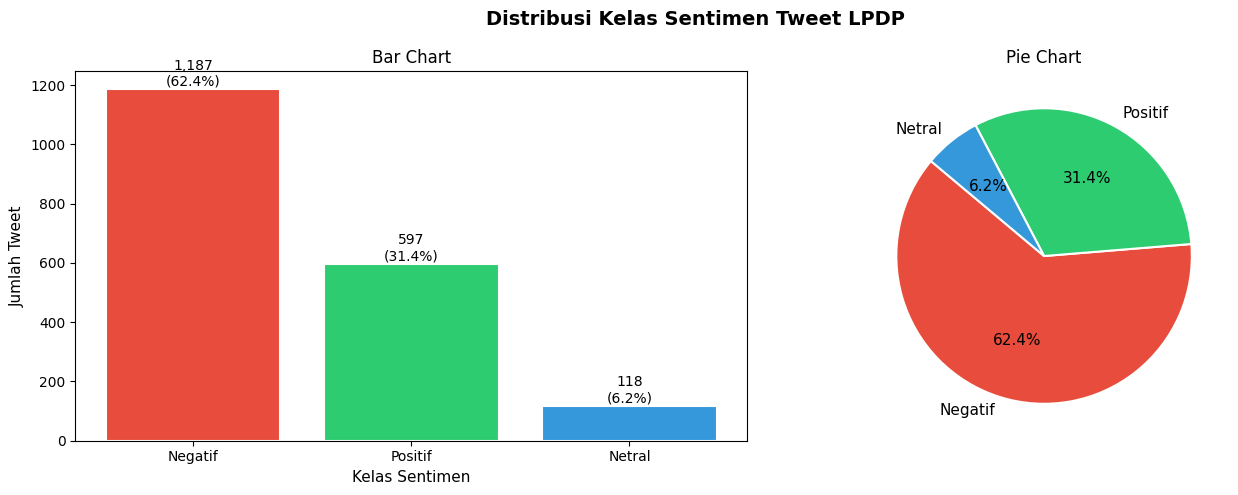

✅ Plot distribusi sentimen ditampilkan.


In [ ]:
"""
Visualisasi proporsi kelas sentimen dalam bentuk:
  - Bar chart dengan label jumlah & persentase
  - Pie chart dengan persentase
"""

dist   = df["label"].value_counts()
labels = dist.index.tolist()
counts = dist.values.tolist()
colors = [SENTIMENT_COLORS.get(l, "#95a5a6") for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Kelas Sentimen Tweet LPDP", fontsize=14, fontweight="bold")

# Bar chart
bars = axes[0].bar(labels, counts, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_xlabel("Kelas Sentimen", fontsize=11)
axes[0].set_ylabel("Jumlah Tweet", fontsize=11)
axes[0].set_title("Bar Chart", fontsize=12)
for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{count:,}\n({count/len(df)*100:.1f}%)",
        ha="center", va="bottom", fontsize=10,
    )

# Pie chart
axes[1].pie(
    counts, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11},
)
axes[1].set_title("Pie Chart", fontsize=12)

plt.tight_layout()
plt.show()
print("✅ Plot distribusi sentimen ditampilkan.")

### WordCloud Keseluruhan

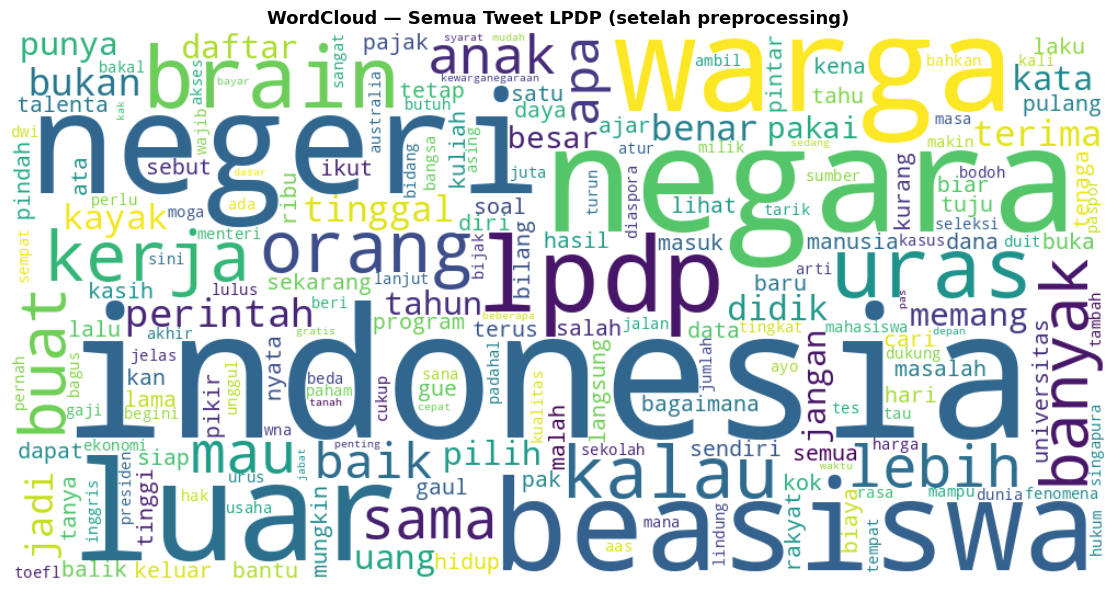

✅ WordCloud keseluruhan ditampilkan.


In [ ]:
"""
Membuat WordCloud dari seluruh tweet yang sudah diproses.
Ukuran kata mencerminkan frekuensinya dalam dataset.
"""

corpus_all = " ".join(df["processed_text"].dropna())

wc_all = WordCloud(
    background_color="white",
    max_words=200,
    colormap="viridis",
    width=1000, height=500,
    collocations=False,
).generate(corpus_all)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc_all, interpolation="bilinear")
ax.axis("off")
ax.set_title("WordCloud — Semua Tweet LPDP (setelah preprocessing)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("✅ WordCloud keseluruhan ditampilkan.")

### WordCloud per Kelas Sentimen

  [Positif] : 597 tweet
  [Netral] : 118 tweet
  [Negatif] : 1,187 tweet


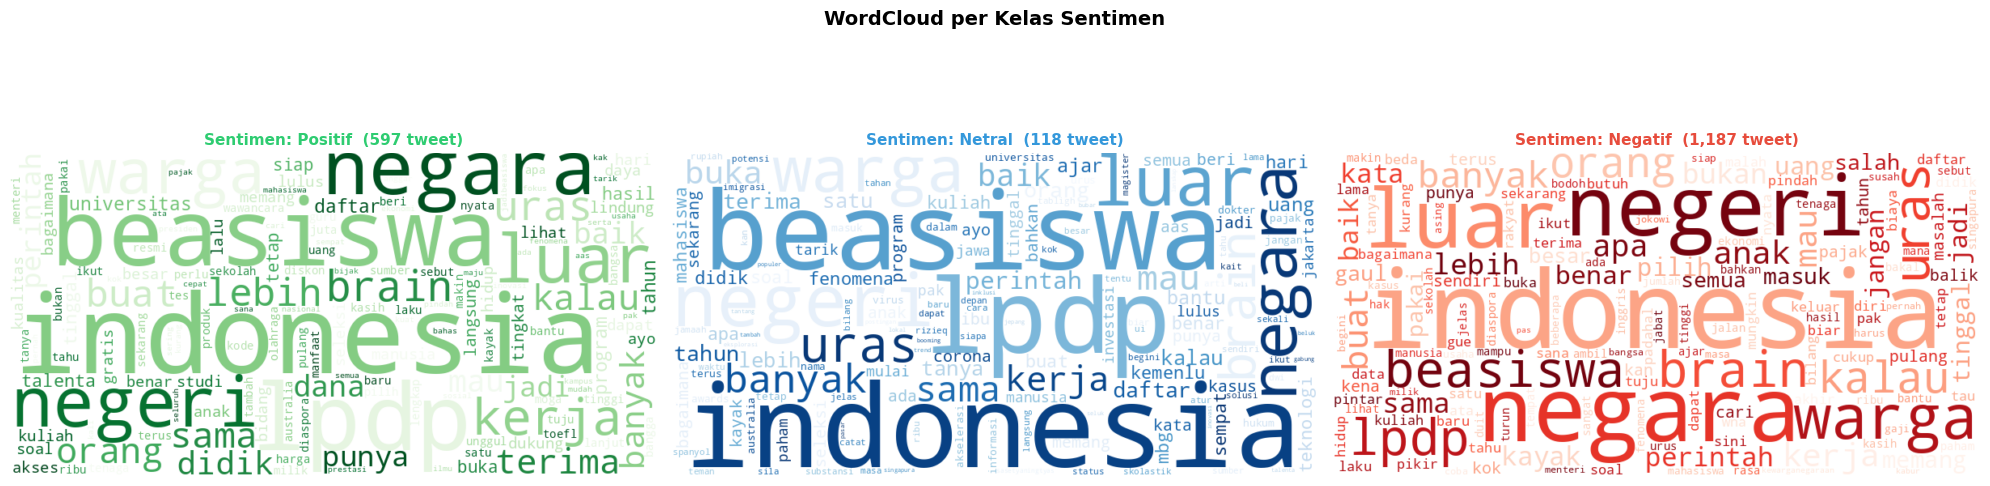

✅ WordCloud per kelas sentimen ditampilkan.


In [ ]:
"""
Membuat WordCloud terpisah untuk setiap kelas sentimen
sehingga karakteristik kata pada tiap kelas terlihat jelas.
"""

cmap_map = {"Positif": "Greens", "Netral": "Blues", "Negatif": "Reds"}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("WordCloud per Kelas Sentimen", fontsize=14, fontweight="bold")

for ax, kelas in zip(axes, ["Positif", "Netral", "Negatif"]):
    subset = df[df["label"] == kelas]["processed_text"]
    print(f"  [{kelas}] : {len(subset):,} tweet")
    if subset.empty:
        ax.axis("off")
        ax.set_title(f"{kelas} (tidak ada data)", fontsize=11)
        continue
    corpus = " ".join(subset.dropna())
    wc = WordCloud(
        background_color="white", max_words=150,
        colormap=cmap_map.get(kelas, "Blues"),
        width=800, height=400, collocations=False,
    ).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(
        f"Sentimen: {kelas}  ({len(subset):,} tweet)",
        fontsize=11, fontweight="bold",
        color=SENTIMENT_COLORS.get(kelas, "black"),
    )

plt.tight_layout()
plt.show()
print("✅ WordCloud per kelas sentimen ditampilkan.")

### Frekuensi Kata (Top-20 Bar Chart)

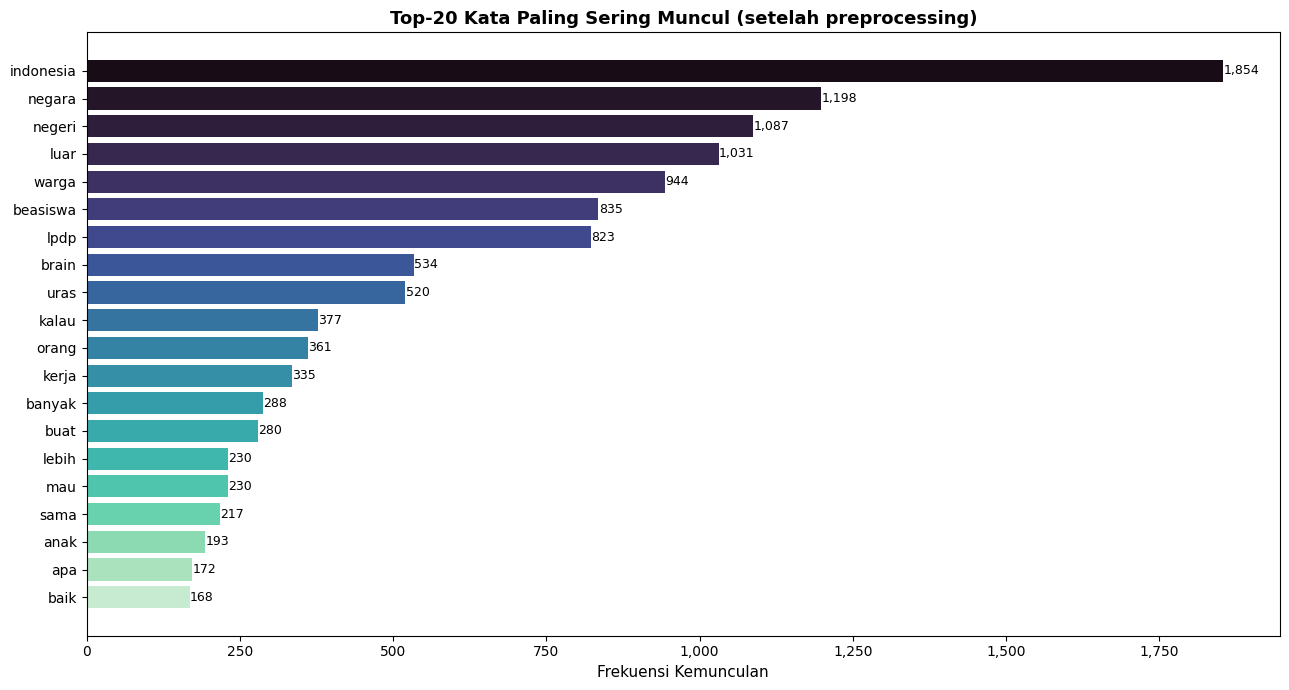

✅ Bar chart frekuensi kata ditampilkan.


In [ ]:
"""
Menghitung dan memvisualisasikan 20 kata yang paling sering muncul
setelah seluruh tahap preprocessing selesai dijalankan.
"""

all_words   = " ".join(df["processed_text"].dropna()).split()
freq        = Counter(all_words).most_common(20)
words_top, counts_top = zip(*freq)

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette("mako_r", len(words_top))
bars = ax.barh(
    list(words_top)[::-1],
    list(counts_top)[::-1],
    color=palette,
)

ax.set_xlabel("Frekuensi Kemunculan", fontsize=11)
ax.set_title(
    "Top-20 Kata Paling Sering Muncul (setelah preprocessing)",
    fontsize=13, fontweight="bold",
)
for bar, count in zip(bars, list(counts_top)[::-1]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center", fontsize=9,
    )
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()
print("✅ Bar chart frekuensi kata ditampilkan.")

### Tren Sentimen per Bulan

  Data dengan waktu valid : 1,902 dari 1,902 baris


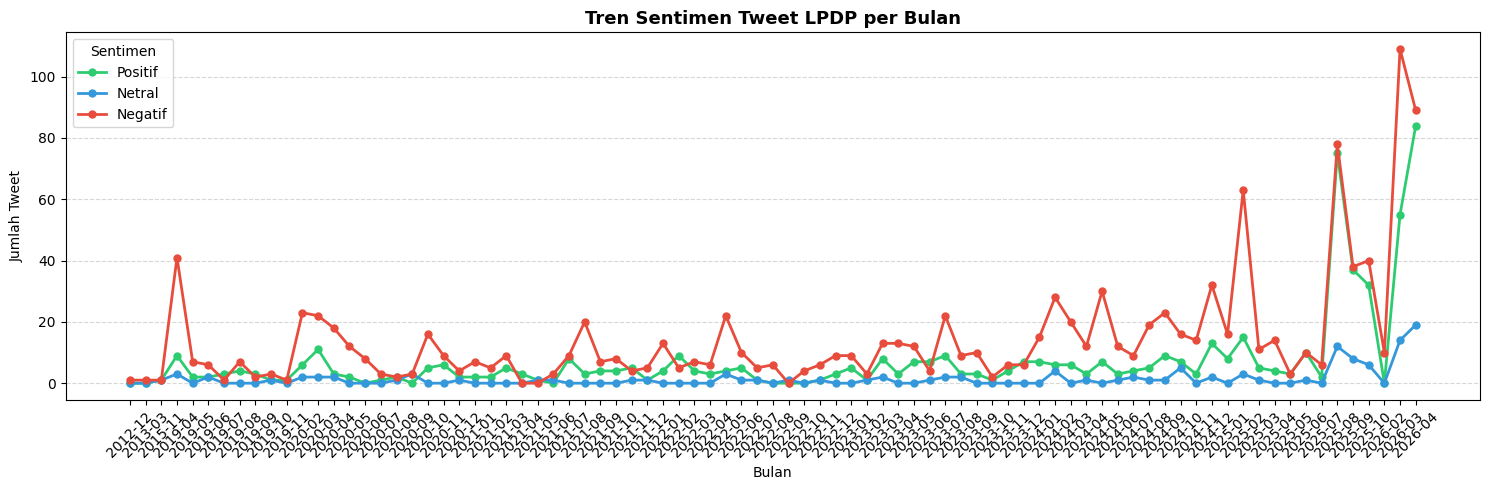

✅ Line chart tren per bulan ditampilkan.


In [ ]:
"""
Memvisualisasikan jumlah tweet per kelas sentimen dari waktu ke waktu
(per bulan), menunjukkan pola dan fluktuasi sentimen LPDP sepanjang periode.
"""

# Parse kolom waktu
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
df_time = df.dropna(subset=["created_at"]).copy()

print(f"  Data dengan waktu valid : {len(df_time):,} dari {len(df):,} baris")

if not df_time.empty:
    df_time["bulan"] = df_time["created_at"].dt.to_period("M").astype(str)
    pivot_bulan = (
        df_time.groupby(["bulan", "label"])
        .size().unstack(fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(15, 5))
    for kelas in ["Positif", "Netral", "Negatif"]:
        if kelas in pivot_bulan.columns:
            ax.plot(
                pivot_bulan.index.astype(str),
                pivot_bulan[kelas],
                marker="o", markersize=5, linewidth=2,
                label=kelas, color=SENTIMENT_COLORS[kelas],
            )
    ax.set_title("Tren Sentimen Tweet LPDP per Bulan", fontsize=13, fontweight="bold")
    ax.set_xlabel("Bulan")
    ax.set_ylabel("Jumlah Tweet")
    ax.legend(title="Sentimen")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    print("✅ Line chart tren per bulan ditampilkan.")
else:
    print("⚠️  Tidak ada data waktu valid untuk visualisasi tren.")

### Tren Sentimen per Hari & per Jam

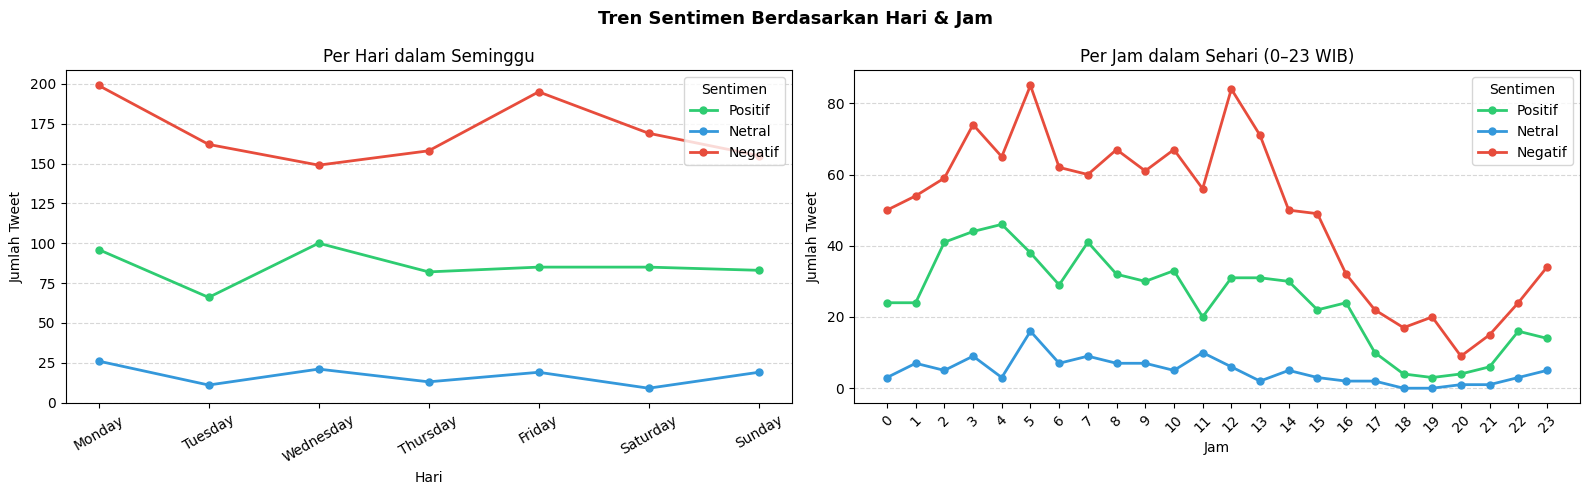

✅ Line chart tren per hari & jam ditampilkan.


In [ ]:
"""
Dua visualisasi tambahan tren waktu:
  - Per hari dalam seminggu (Monday–Sunday)
  - Per jam dalam sehari (0–23)
untuk memahami pola aktivitas tweet berdasarkan waktu.
"""

if not df_time.empty:
    df_time["hari"] = df_time["created_at"].dt.day_name()
    df_time["jam"]  = df_time["created_at"].dt.hour

    hari_urut = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Tren Sentimen Berdasarkan Hari & Jam", fontsize=13, fontweight="bold")

    # Per hari
    pivot_hari = (
        df_time.groupby(["hari", "label"])
        .size().unstack(fill_value=0)
        .reindex([h for h in hari_urut if h in df_time["hari"].unique()])
    )
    for kelas in ["Positif", "Netral", "Negatif"]:
        if kelas in pivot_hari.columns:
            axes[0].plot(
                pivot_hari.index.astype(str), pivot_hari[kelas],
                marker="o", markersize=5, linewidth=2,
                label=kelas, color=SENTIMENT_COLORS[kelas],
            )
    axes[0].set_title("Per Hari dalam Seminggu")
    axes[0].set_xlabel("Hari")
    axes[0].set_ylabel("Jumlah Tweet")
    axes[0].legend(title="Sentimen")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    # Per jam
    pivot_jam = (
        df_time.groupby(["jam", "label"])
        .size().unstack(fill_value=0)
        .sort_index()
    )
    for kelas in ["Positif", "Netral", "Negatif"]:
        if kelas in pivot_jam.columns:
            axes[1].plot(
                pivot_jam.index.astype(str), pivot_jam[kelas],
                marker="o", markersize=5, linewidth=2,
                label=kelas, color=SENTIMENT_COLORS[kelas],
            )
    axes[1].set_title("Per Jam dalam Sehari (0–23 WIB)")
    axes[1].set_xlabel("Jam")
    axes[1].set_ylabel("Jumlah Tweet")
    axes[1].legend(title="Sentimen")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
    print("✅ Line chart tren per hari & jam ditampilkan.")
else:
    print("⚠️  Tidak ada data waktu valid.")

# DATA PREPARATION

### TF-IDF & Encoding Label

In [ ]:
"""
Persiapan data untuk pemodelan:
  1. Label encoding  : konversi kelas string → angka menggunakan LabelEncoder
  2. TF-IDF          : ekstraksi fitur numerik dari teks
     - sublinear_tf  : log(TF) meredam dominasi kata frekuensi tinggi
     - ngram_range   : unigram + bigram untuk menangkap frasa pendek
     - max_features  : batas 20.000 fitur agar tidak terlalu sparse
     - min_df=3      : abaikan kata yang < 3 dokumen (noise)
"""

print("🔧 Persiapan data ...")

# Bersihkan NaN pada kolom teks
df["processed_text"] = df["processed_text"].fillna("")

X = df["processed_text"]
y_raw = df["label"]

# ── Label Encoding ────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(y_raw)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\n  Label mapping  : {label_mapping}")
print(f"  Distribusi y   :")
for cls, enc in label_mapping.items():
    print(f"    {cls} ({enc}) : {(y == enc).sum():,}")

# ── TF-IDF Vectorization ──────────────────────────────────────
print("\n🔧 Membuat TF-IDF Vectorizer ...")
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    min_df=3,
    max_features=20_000,
    ngram_range=(1, 2),
    analyzer="word",
)
X_tfidf = tfidf.fit_transform(X)

print(f"  Shape matriks TF-IDF  : {X_tfidf.shape}")
print(f"  Jumlah fitur (vocab)  : {len(tfidf.vocabulary_):,}")


🔧 Persiapan data ...

  Label mapping  : {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}
  Distribusi y   :
    Negatif (0) : 1,187
    Netral (1) : 118
    Positif (2) : 597

🔧 Membuat TF-IDF Vectorizer ...
  Shape matriks TF-IDF  : (1902, 3090)
  Jumlah fitur (vocab)  : 3,090


### Train-Test Split

In [ ]:
"""
Membagi data menjadi 80% latih dan 20% uji.
Stratify digunakan agar proporsi kelas terjaga di kedua set.
"""

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("✅ Train-Test Split selesai (80 : 20):\n")
print(f"  Data latih (X_train) : {X_train.shape[0]:,} sampel  | shape: {X_train.shape}")
print(f"  Data uji   (X_test)  : {X_test.shape[0]:,} sampel  | shape: {X_test.shape}")

print(f"\n  Distribusi kelas di data latih:")
for cls, enc in label_mapping.items():
    n = (y_train == enc).sum()
    print(f"    {cls:<10} ({enc}): {n:,}  ({n/len(y_train)*100:.1f}%)")

print(f"\n  Distribusi kelas di data uji:")
for cls, enc in label_mapping.items():
    n = (y_test == enc).sum()
    print(f"    {cls:<10} ({enc}): {n:,}  ({n/len(y_test)*100:.1f}%)")

✅ Train-Test Split selesai (80 : 20):

  Data latih (X_train) : 1,521 sampel  | shape: (1521, 3090)
  Data uji   (X_test)  : 381 sampel  | shape: (381, 3090)

  Distribusi kelas di data latih:
    Negatif    (0): 949  (62.4%)
    Netral     (1): 94  (6.2%)
    Positif    (2): 478  (31.4%)

  Distribusi kelas di data uji:
    Negatif    (0): 238  (62.5%)
    Netral     (1): 24  (6.3%)
    Positif    (2): 119  (31.2%)


# BUILD & TRAIN

### Base Random Forest Model

In [ ]:
"""
Melatih model Random Forest Classifier dasar (sebelum tuning).
Parameter awal dipilih agar model tidak terlalu overfitting:
  - n_estimators=200    : 200 pohon keputusan
  - class_weight=balanced : otomatis tangani imbalanced class
  - max_features=sqrt   : √n_fitur dipertimbangkan per split
"""

print("🤖 Melatih model Random Forest (Base) ...")
print("   Parameter: n_estimators=200, class_weight='balanced', max_features='sqrt'")

rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf_base.fit(X_train, y_train)
print("\n✅ Training selesai!")
print(f"  Jumlah pohon   : {rf_base.n_estimators}")
print(f"  Jumlah kelas   : {rf_base.n_classes_}")
print(f"  Kelas          : {list(le.classes_)}")


🤖 Melatih model Random Forest (Base) ...
   Parameter: n_estimators=200, class_weight='balanced', max_features='sqrt'

✅ Training selesai!
  Jumlah pohon   : 200
  Jumlah kelas   : 3
  Kelas          : ['Negatif', 'Netral', 'Positif']


# EVALUASI

### Base Model (Accuracy + Report)

In [ ]:
"""
Mengevaluasi performa model dasar pada data uji:
  - Akurasi keseluruhan
  - Precision, Recall, F1 per kelas
"""

y_pred_base = rf_base.predict(X_test)
acc_base    = accuracy_score(y_test, y_pred_base)

print("=" * 55)
print("📊 EVALUASI BASE MODEL — RANDOM FOREST")
print("=" * 55)
print(f"\n  Akurasi  : {acc_base:.4f}  ({acc_base*100:.2f}%)")
print(f"\n  Classification Report:")
print(classification_report(
    y_test, y_pred_base,
    target_names=le.classes_,
))

📊 EVALUASI BASE MODEL — RANDOM FOREST

  Akurasi  : 0.7060  (70.60%)

  Classification Report:
              precision    recall  f1-score   support

     Negatif       0.75      0.85      0.80       238
      Netral       0.33      0.21      0.26        24
     Positif       0.65      0.52      0.58       119

    accuracy                           0.71       381
   macro avg       0.58      0.53      0.54       381
weighted avg       0.69      0.71      0.69       381



### Confusion Matrix Base Model

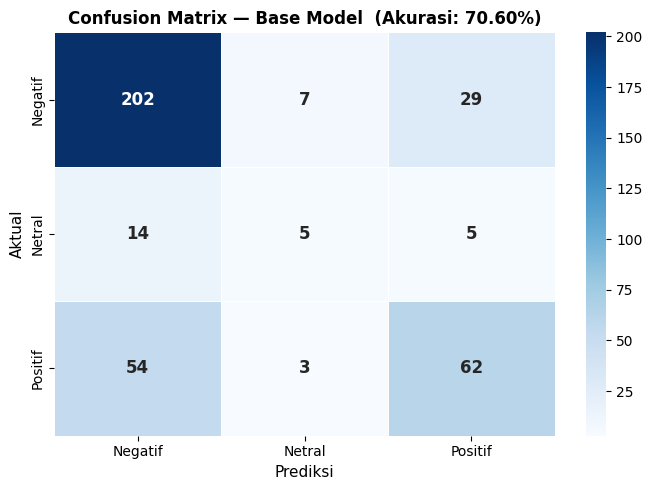

✅ Confusion Matrix Base Model ditampilkan.


In [ ]:
"""
Menampilkan Confusion Matrix dalam bentuk heatmap berwarna
untuk melihat distribusi prediksi benar dan salah per kelas.
"""

cm_base = confusion_matrix(y_test, y_pred_base)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_base, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
)
ax.set_xlabel("Prediksi", fontsize=11)
ax.set_ylabel("Aktual", fontsize=11)
ax.set_title(
    f"Confusion Matrix — Base Model  (Akurasi: {acc_base*100:.2f}%)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()
print("✅ Confusion Matrix Base Model ditampilkan.")

# HYPERPARAMETER TUNING

### Setup RandomizedSearchC

In [ ]:
"""
Mendefinisikan ruang pencarian hyperparameter dan konfigurasi
RandomizedSearchCV untuk optimasi model Random Forest.

Mengapa RandomizedSearchCV?
  GridSearchCV mencoba SEMUA kombinasi (bisa ratusan iterasi).
  RandomizedSearchCV hanya mencoba n_iter kombinasi acak —
  lebih efisien dengan hasil mendekati optimal.

Metrik: f1_macro — cocok untuk multi-kelas dengan potensi imbalance,
  karena menghitung rata-rata F1 tiap kelas tanpa pembobotan.
"""

from scipy.stats import randint

param_distributions = {
    "n_estimators":      [100, 200, 300, 400, 500],
    "max_depth":         [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf":  [1, 2, 4, 6],
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
    "bootstrap":         [True, False],
}

rf_tuning = RandomForestClassifier(
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=30,              # Coba 30 kombinasi acak
    scoring="f1_macro",     # Metrik optimasi
    cv=5,                   # 5-fold cross-validation
    refit=True,             # Latih ulang model terbaik di seluruh data latih
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

print("✅ RandomizedSearchCV dikonfigurasi:")
print(f"  n_iter     : 30 kombinasi acak")
print(f"  cv         : 5-fold")
print(f"  scoring    : f1_macro")
print(f"  Parameter yang dicari:")
for k, v in param_distributions.items():
    print(f"    {k:<25} : {v}")

✅ RandomizedSearchCV dikonfigurasi:
  n_iter     : 30 kombinasi acak
  cv         : 5-fold
  scoring    : f1_macro
  Parameter yang dicari:
    n_estimators              : [100, 200, 300, 400, 500]
    max_depth                 : [None, 10, 20, 30, 50]
    min_samples_split         : [2, 5, 10, 15]
    min_samples_leaf          : [1, 2, 4, 6]
    max_features              : ['sqrt', 'log2', 0.3, 0.5]
    bootstrap                 : [True, False]


# EVALUASI

### Jalankan Pencarian

In [ ]:
"""
Menjalankan proses pencarian hyperparameter terbaik.
Proses ini membutuhkan waktu (30 iterasi × 5-fold = 150 model).
"""

print("🚀 Menjalankan RandomizedSearchCV ... (sabar ya, ini proses terberat)")
print("   30 iterasi × 5-fold CV = 150 model yang dilatih\n")

search.fit(X_train, y_train)

best_model  = search.best_estimator_
best_params = search.best_params_
best_score  = search.best_score_

print(f"\n✅ Pencarian selesai!")
print(f"\n🎯 Best CV Score (F1 Macro) : {best_score:.4f}")
print(f"\n📋 Hyperparameter Terbaik:")
for k, v in best_params.items():
    print(f"  {k:<30} : {v}")

🚀 Menjalankan RandomizedSearchCV ... (sabar ya, ini proses terberat)
   30 iterasi × 5-fold CV = 150 model yang dilatih

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Pencarian selesai!

🎯 Best CV Score (F1 Macro) : 0.5505

📋 Hyperparameter Terbaik:
  n_estimators                   : 500
  min_samples_split              : 2
  min_samples_leaf               : 1
  max_features                   : log2
  max_depth                      : 20
  bootstrap                      : False


### Best Model (Tuned)

In [ ]:
"""
Mengevaluasi ulang model terbaik hasil tuning pada data uji.
Bandingkan dengan akurasi Base Model untuk melihat peningkatan.
"""

y_pred_best = best_model.predict(X_test)
acc_best    = accuracy_score(y_test, y_pred_best)

print("=" * 55)
print("📊 EVALUASI MODEL TERBAIK — RANDOM FOREST (TUNED)")
print("=" * 55)
print(f"\n  Akurasi  : {acc_best:.4f}  ({acc_best*100:.2f}%)")
print(f"\n  Classification Report:")
print(classification_report(
    y_test, y_pred_best,
    target_names=le.classes_,
))

📊 EVALUASI MODEL TERBAIK — RANDOM FOREST (TUNED)

  Akurasi  : 0.6824  (68.24%)

  Classification Report:
              precision    recall  f1-score   support

     Negatif       0.74      0.83      0.78       238
      Netral       0.28      0.29      0.29        24
     Positif       0.63      0.46      0.53       119

    accuracy                           0.68       381
   macro avg       0.55      0.53      0.53       381
weighted avg       0.67      0.68      0.67       381



### Confusion Matrix Model Terbaik

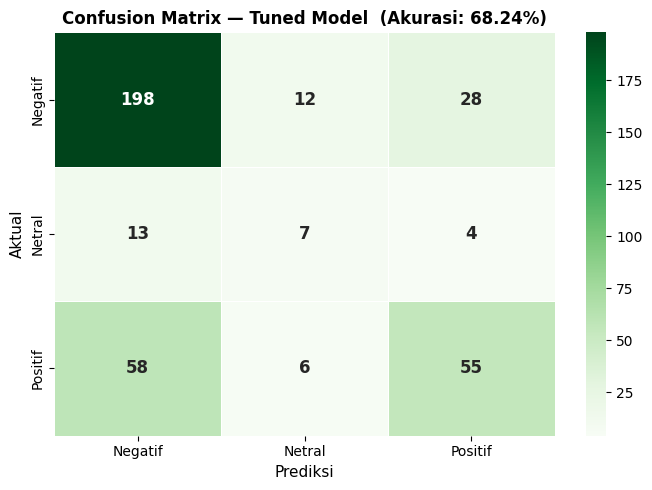

✅ Confusion Matrix Tuned Model ditampilkan.


In [ ]:
"""
Confusion Matrix model setelah hyperparameter tuning.
"""

cm_best = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="Greens",
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
)
ax.set_xlabel("Prediksi", fontsize=11)
ax.set_ylabel("Aktual", fontsize=11)
ax.set_title(
    f"Confusion Matrix — Tuned Model  (Akurasi: {acc_best*100:.2f}%)",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()
print("✅ Confusion Matrix Tuned Model ditampilkan.")

### Perbandingan Base vs Tuned Model

In [ ]:
"""
Ringkasan perbandingan performa Base Model dan Tuned Model
dalam satu tabel agar mudah dibandingkan untuk skripsi.
"""

from sklearn.metrics import f1_score, precision_score, recall_score

def ringkasan_metrik(y_true, y_pred, nama: str) -> dict:
    return {
        "Model"    : nama,
        "Akurasi"  : f"{accuracy_score(y_true, y_pred):.4f}",
        "F1 Macro" : f"{f1_score(y_true, y_pred, average='macro'):.4f}",
        "F1 Weighted": f"{f1_score(y_true, y_pred, average='weighted'):.4f}",
        "Precision Macro": f"{precision_score(y_true, y_pred, average='macro'):.4f}",
        "Recall Macro"   : f"{recall_score(y_true, y_pred, average='macro'):.4f}",
    }

rows = [
    ringkasan_metrik(y_test, y_pred_base, "Random Forest Base"),
    ringkasan_metrik(y_test, y_pred_best, "Random Forest Tuned"),
]
df_compare = pd.DataFrame(rows).set_index("Model")

print("=" * 65)
print("📊 RINGKASAN PERBANDINGAN PERFORMA MODEL")
print("=" * 65)
print(df_compare.to_string())

delta_acc = acc_best - acc_base
print(f"\n  Peningkatan Akurasi setelah tuning : {delta_acc:+.4f} ({delta_acc*100:+.2f}%)")

📊 RINGKASAN PERBANDINGAN PERFORMA MODEL
                    Akurasi F1 Macro F1 Weighted Precision Macro Recall Macro
Model                                                                        
Random Forest Base   0.7060   0.5428      0.6931          0.5758       0.5260
Random Forest Tuned  0.6824   0.5336      0.6727          0.5494       0.5286

  Peningkatan Akurasi setelah tuning : -0.0236 (-2.36%)


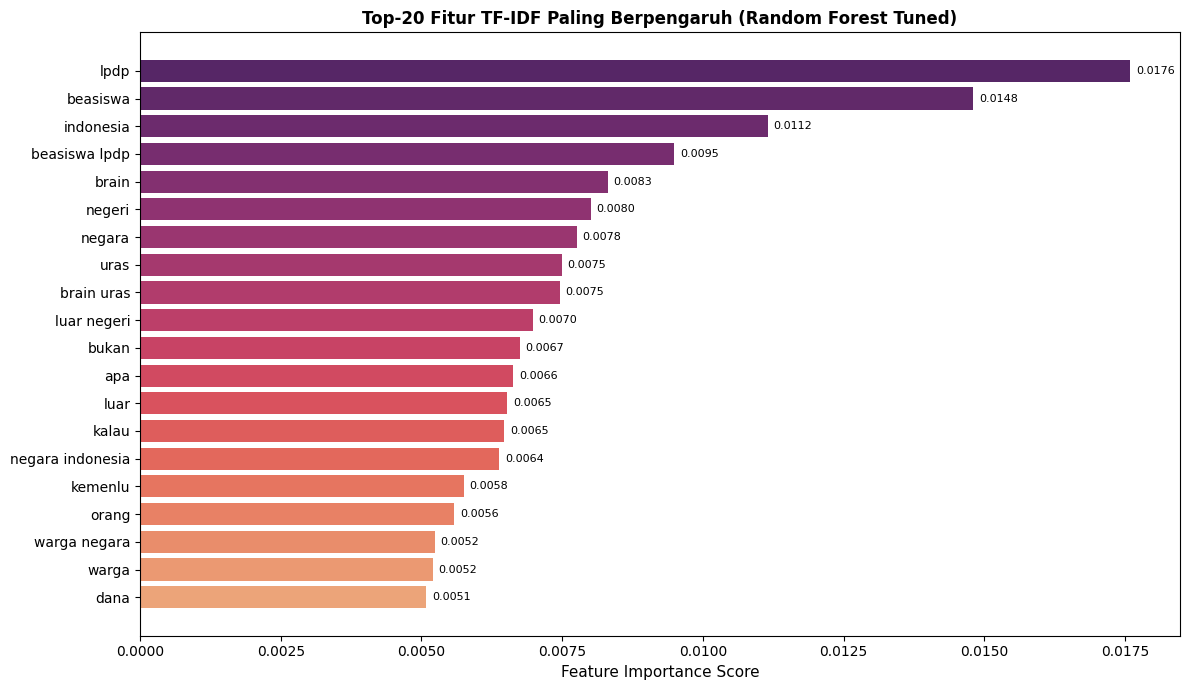

✅ Feature importance ditampilkan.

  Top-10 fitur paling berpengaruh:
    lpdp                           : 0.01760
    beasiswa                       : 0.01481
    indonesia                      : 0.01116
    beasiswa lpdp                  : 0.00949
    brain                          : 0.00831
    negeri                         : 0.00800
    negara                         : 0.00776
    uras                           : 0.00749
    brain uras                     : 0.00746
    luar negeri                    : 0.00698


In [ ]:
"""
Menampilkan 20 fitur (kata/bigram) yang paling berpengaruh
terhadap keputusan prediksi model Random Forest.
Berguna untuk validasi apakah model belajar dari kata yang tepat.
"""

importances = best_model.feature_importances_
feat_names  = tfidf.get_feature_names_out()
top_idx     = np.argsort(importances)[::-1][:20]

df_imp = pd.DataFrame({
    "Fitur"      : feat_names[top_idx],
    "Importance" : importances[top_idx],
})

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("flare", len(df_imp))
ax.barh(df_imp["Fitur"][::-1], df_imp["Importance"][::-1], color=palette)
ax.set_xlabel("Feature Importance Score", fontsize=11)
ax.set_title("Top-20 Fitur TF-IDF Paling Berpengaruh (Random Forest Tuned)",
             fontsize=12, fontweight="bold")
for i, (val, name) in enumerate(zip(df_imp["Importance"][::-1], df_imp["Fitur"][::-1])):
    ax.text(val + 0.0001, i, f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()
print("✅ Feature importance ditampilkan.")
print("\n  Top-10 fitur paling berpengaruh:")
for _, row in df_imp.head(10).iterrows():
    print(f"    {row['Fitur']:<30} : {row['Importance']:.5f}")

# SAVE MODEL

In [ ]:
"""
Menyimpan artefak model ke folder lokal 'weights/random-forest/':
  - best_model.pkl       : model Random Forest terbaik (hasil tuning)
  - tfidf_vectorizer.pkl : TF-IDF vectorizer (harus sama saat inference)
  - label_encoder.pkl    : LabelEncoder (mapping angka → label)
  - metadata.json        : info performa & parameter terbaik
"""

MODEL_DIR = "weights/random-forest"
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Simpan model ──────────────────────────────────────────────
model_path = os.path.join(MODEL_DIR, "best_model.pkl")
joblib.dump(best_model, model_path)
print(f"✅ Model disimpan       → {model_path}")

# ── Simpan TF-IDF ─────────────────────────────────────────────
tfidf_path = os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")
joblib.dump(tfidf, tfidf_path)
print(f"✅ TF-IDF disimpan      → {tfidf_path}")

# ── Simpan LabelEncoder ───────────────────────────────────────
le_path = os.path.join(MODEL_DIR, "label_encoder.pkl")
joblib.dump(le, le_path)
print(f"✅ LabelEncoder disimpan → {le_path}")

# ── Simpan Metadata JSON ──────────────────────────────────────
metadata = {
    "created_at"  : datetime.now().isoformat(),
    "model_type"  : "RandomForestClassifier",
    "classes"     : le.classes_.tolist(),
    "label_mapping": {k: int(v) for k, v in label_mapping.items()},
    "best_params" : {k: (str(v) if v is None else v) for k, v in best_params.items()},
    "performance" : {
        "base_model_accuracy"  : round(acc_base, 4),
        "tuned_model_accuracy" : round(acc_best, 4),
        "f1_macro_tuned"       : round(float(f1_score(y_test, y_pred_best, average="macro")), 4),
    },
    "vectorizer_config": {
        "max_features"  : tfidf.max_features,
        "ngram_range"   : list(tfidf.ngram_range),
        "sublinear_tf"  : tfidf.sublinear_tf,
        "min_df"        : tfidf.min_df,
    },
}
meta_path = os.path.join(MODEL_DIR, "metadata.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Metadata disimpan    → {meta_path}")

print(f"\n🎉 Semua artefak tersimpan di folder: '{MODEL_DIR}/'")
print(f"   Isi folder:")
for fname in os.listdir(MODEL_DIR):
    fpath = os.path.join(MODEL_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"   {'📄' if fname.endswith('.json') else '💾'}  {fname:<30}  ({size:.1f} KB)")


✅ Model disimpan       → weights/random-forest/best_model.pkl
✅ TF-IDF disimpan      → weights/random-forest/tfidf_vectorizer.pkl
✅ LabelEncoder disimpan → weights/random-forest/label_encoder.pkl
✅ Metadata disimpan    → weights/random-forest/metadata.json

🎉 Semua artefak tersimpan di folder: 'weights/random-forest/'
   Isi folder:
   💾  label_encoder.pkl               (0.5 KB)
   📄  metadata.json                   (0.7 KB)
   💾  best_model.pkl                  (9958.0 KB)
   💾  tfidf_vectorizer.pkl            (118.4 KB)


# INFERENCE

### Load Model & Definisi Fungsi Prediksi

In [ ]:
"""
Memuat model dan vectorizer dari disk, lalu mendefinisikan
fungsi predict_sentiment() untuk prediksi teks baru.

Alur inference:
  teks mentah → preprocessing → TF-IDF transform → prediksi → label + confidence
"""

print("📂 Memuat model dari disk ...")

loaded_model = joblib.load(os.path.join(MODEL_DIR, "best_model.pkl"))
loaded_tfidf = joblib.load(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))
loaded_le    = joblib.load(os.path.join(MODEL_DIR, "label_encoder.pkl"))

print(f"  ✅ best_model.pkl       dimuat")
print(f"  ✅ tfidf_vectorizer.pkl dimuat")
print(f"  ✅ label_encoder.pkl    dimuat")
print(f"  Kelas yang dikenali : {list(loaded_le.classes_)}")


def predict_sentiment(text: str, model_dir: str = MODEL_DIR) -> dict:
    """
    Memprediksi sentimen untuk satu teks baru.

    Parameters
    ----------
    text      : str — Teks mentah yang ingin diprediksi
    model_dir : str — Direktori model (default: 'weights/random-forest')

    Returns
    -------
    dict dengan keys:
        'teks_asli'   — Input mentah
        'teks_proses' — Teks setelah preprocessing
        'sentimen'    — Hasil kelas: 'Positif' / 'Negatif' / 'Netral'
        'confidence'  — Probabilitas kelas tertinggi (0.0–1.0)
        'prob_detail' — Probabilitas semua kelas {kelas: prob}
    """
    # Preprocessing teks baru (tanpa filter bahasa agar tidak membuang teks pendek)
    teks_proses = filter_teks(text)
    teks_proses = case_folding(teks_proses)
    teks_proses = normalisasi_kata(teks_proses, kamus_baku)
    teks_proses = hapus_stopwords(teks_proses, stopwords_set)
    teks_proses = lakukan_stemming(teks_proses, stemmer)

    # Jika teks kosong setelah preprocessing
    if not teks_proses.strip():
        return {
            "teks_asli"  : text,
            "teks_proses": teks_proses,
            "sentimen"   : "Netral",
            "confidence" : 0.0,
            "prob_detail": {cls: 0.0 for cls in loaded_le.classes_},
        }

    # Transformasi TF-IDF
    X_infer = loaded_tfidf.transform([teks_proses])

    # Prediksi kelas & probabilitas
    pred_enc   = loaded_model.predict(X_infer)[0]
    pred_proba = loaded_model.predict_proba(X_infer)[0]
    pred_label = loaded_le.inverse_transform([pred_enc])[0]
    classes    = loaded_le.classes_
    prob_dict  = {cls: round(float(p), 4) for cls, p in zip(classes, pred_proba)}

    return {
        "teks_asli"  : text,
        "teks_proses": teks_proses,
        "sentimen"   : pred_label,
        "confidence" : round(float(pred_proba.max()), 4),
        "prob_detail": prob_dict,
    }

print("\n✅ Fungsi predict_sentiment() siap digunakan.")


📂 Memuat model dari disk ...
  ✅ best_model.pkl       dimuat
  ✅ tfidf_vectorizer.pkl dimuat
  ✅ label_encoder.pkl    dimuat
  Kelas yang dikenali : ['Negatif', 'Netral', 'Positif']

✅ Fungsi predict_sentiment() siap digunakan.


### 3 Contoh Prediksi Sentimen

In [ ]:
"""
Mendemonstrasikan predict_sentiment() dengan 3 teks bertema LPDP
yang mewakili kelas Positif, Negatif, dan Netral.
"""

EMOJI_MAP = {"Positif": "😊", "Negatif": "😠", "Netral": "😐"}

contoh_prediksi = [
    # ── Contoh 1 : Sentimen Positif ──────────────────────────
    "Alhamdulillah akhirnya lolos LPDP! Bangga banget, "
    "programnya bener-bener membantu anak bangsa buat lanjut S2 ke luar negeri. "
    "Terima kasih LPDP, semangat buat yang masih berjuang!",

    # ── Contoh 2 : Sentimen Negatif ──────────────────────────
    "Proses seleksi LPDP sangat mengecewakan, dokumen adminnya ribet banget "
    "dan syaratnya sering berubah tanpa pemberitahuan yang jelas. "
    "Banyak pelamar berprestasi yang gagal hanya karena birokrasi amburadul.",

    # ── Contoh 3 : Sentimen Netral ───────────────────────────
    "LPDP membuka pendaftaran beasiswa reguler dalam negeri dan luar negeri. "
    "Kuota yang tersedia tahun ini sebanyak 4.000 awardee. "
    "Batas waktu pendaftaran adalah 30 Juni, persyaratan lengkap di web resmi LPDP.",
]

print("=" * 65)
print("🔮 HASIL PREDIKSI SENTIMEN — 3 CONTOH TEKS")
print("=" * 65)

hasil_list = []
for i, teks in enumerate(contoh_prediksi, 1):
    hasil = predict_sentiment(teks)
    hasil_list.append(hasil)

    emoji = EMOJI_MAP.get(hasil["sentimen"], "❓")
    print(f"\n  {'─' * 60}")
    print(f"  Contoh {i}:")
    print(f"  📝 Input     : {teks[:85]}{'...' if len(teks) > 85 else ''}")
    print(f"  🔧 Proses    : {hasil['teks_proses'][:75]}{'...' if len(hasil['teks_proses']) > 75 else ''}")
    print(f"  {emoji} Sentimen  : {hasil['sentimen'].upper()}")
    print(f"  📈 Confidence: {hasil['confidence']:.2%}")
    print(f"  📊 Prob detail:")
    for kls, prob in hasil["prob_detail"].items():
        bar  = "█" * int(prob * 20)
        mark = " ← terpilih" if kls == hasil["sentimen"] else ""
        print(f"      {kls:<10}: {prob:>6.2%}  {bar}{mark}")

print(f"\n  {'─' * 60}")

# Tampilkan ringkasan dalam tabel
df_hasil = pd.DataFrame([
    {
        "No"        : i + 1,
        "Teks (50 char)" : h["teks_asli"][:50] + "...",
        "Sentimen"  : h["sentimen"],
        "Confidence": f"{h['confidence']:.2%}",
    }
    for i, h in enumerate(hasil_list)
])
print("\n📄 Ringkasan Hasil Prediksi:")
print(df_hasil.to_string(index=False))
print("\n✅ Pipeline selesai! Model siap digunakan untuk analisis sentimen LPDP.")

🔮 HASIL PREDIKSI SENTIMEN — 3 CONTOH TEKS

  ────────────────────────────────────────────────────────────
  Contoh 1:
  📝 Input     : Alhamdulillah akhirnya lolos LPDP! Bangga banget, programnya bener-bener membantu ana...
  🔧 Proses    : alhamdulillah akhir lolos lpdp bangga program benar benar bantu anak bangsa...
  😠 Sentimen  : NEGATIF
  📈 Confidence: 35.29%
  📊 Prob detail:
      Negatif   : 35.29%  ███████ ← terpilih
      Netral    : 30.06%  ██████
      Positif   : 34.65%  ██████

  ────────────────────────────────────────────────────────────
  Contoh 2:
  📝 Input     : Proses seleksi LPDP sangat mengecewakan, dokumen adminnya ribet banget dan syaratnya ...
  🔧 Proses    : proses seleksi lpdp sangat kecewa dokumen adminnya ribet syarat sering ubah...
  😠 Sentimen  : NEGATIF
  📈 Confidence: 35.24%
  📊 Prob detail:
      Negatif   : 35.24%  ███████ ← terpilih
      Netral    : 30.00%  ██████
      Positif   : 34.75%  ██████

  ─────────────────────────────────────────────────────